# Monte Carlo Average Returns in Gridworld
This notebook demonstrates how to estimate state values in a Gridworld environment using the Monte Carlo method with average returns. The agent explores the environment, collects rewards, and updates the value of each state by averaging the returns observed from multiple episodes. The notebook visualizes the reward structure, the learning process, and the resulting value function.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

## Environment and Parameters Setup
We define the reward structure for each state in the 4x4 grid, set the terminal state, initialize the state values, and prepare a log for scores.

In [2]:
rewards = np.zeros(16)
rewards[3] = 1
rewards[2] = 0
rewards[11] = 0
rewards[10] = 0

terminal_state = 3
state_values = np.zeros(16)
score_log = []

## Visualizing the Reward Structure
This cell visualizes the reward values for each state in the 4x4 grid. High and low reward states are easily identified in the plot.

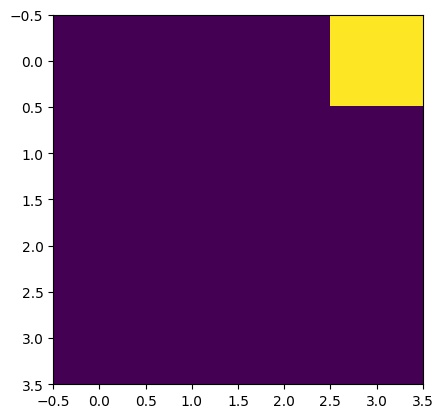

In [3]:
plt.imshow(rewards.reshape(4,4))

## Loading the State Transition Table
We load the state transition table from a CSV file. This table defines how the agent moves between states given an action.

In [4]:
state_transition_table = np.genfromtxt("state_transitions.csv", delimiter=",").astype(int)

## Calculating Average Returns
This function computes the average return for each state by averaging the discounted sum of rewards observed from all visits to that state in an episode.

In [5]:
def returns(rewards, states):
    state_count = np.zeros(16)
    state_returns = np.zeros(16)
    r = 0
    gamma = 0.9
    for i in reversed(range(len(rewards))):
        r = rewards[i] + gamma * r
        state_returns[states[i]] += r
        state_count[states[i]] += 1
#         print(states[i])

    return state_returns/(state_count + 1e-10)

## Agent Evaluation Function
This function simulates the agent's behavior using the current value estimates to select actions, and returns the total reward and the sequence of visited states.

In [6]:
def test_agent():
    state = 12
    steps = 0
    total_rewards = 0
    states_log = []
    while (not(state == terminal_state)) and steps<30:
        states_log.append(state)
        action = np.argmax(state_values[state_transition_table[state]])
        state = state_transition_table[state, action]
        total_rewards += rewards[state]
        steps += 1
    states_log.append(state)
    return total_rewards, states_log

## Monte Carlo Learning: Main Training Loop
This loop runs multiple episodes where the agent explores the environment, collects rewards, and updates the value estimates for each state by averaging the observed returns. The agent's performance is logged for analysis.

In [7]:
returns_log = []
for _ in range(100):
    state = 12
    state_log = []
    reward_log = []
    steps = 0

    while (not(state == terminal_state)) and steps<30:
        reward_log.append(rewards[state])
        state_log.append(state)
        
        action = random.randint(0,3)
        state = state_transition_table[state, action]
        steps += 1
        
    reward_log.append(rewards[state])
    state_log.append(state)
    returns_log.append(returns(reward_log, state_log))
    state_values = np.mean(returns_log, 0)
    
    score_log.append(test_agent()[0])

## Visualizing Returns After a Few Episodes
This cell displays the returns for each state after a few episodes, helping you see how the estimated values evolve during learning.

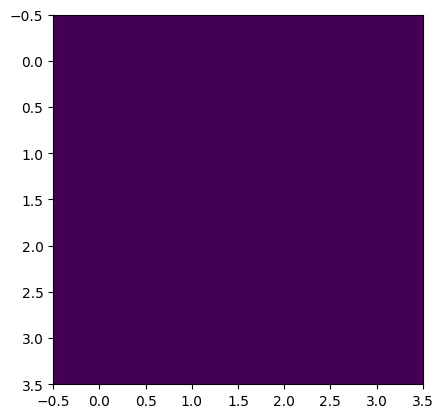

In [8]:
plt.imshow(returns_log[4].reshape(4, 4))

## Visualizing Learned State Values
This cell displays the learned value for each state after training, helping you see which states are considered more valuable by the agent.

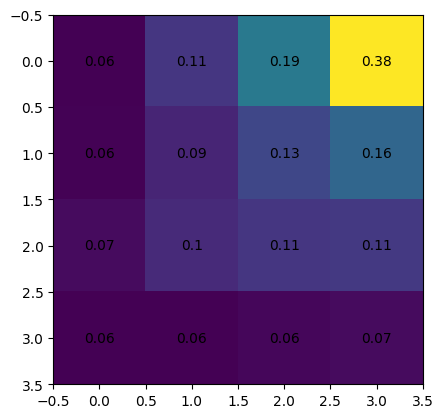

In [9]:
fig1, ax1= plt.subplots(1)
ax1.imshow(state_values.reshape(4, 4))

for (j,i), label in np.ndenumerate(state_values.reshape(4, 4).round(2)):
    ax1.text(i,j,label,ha='center',va='center')

## Plotting the Learning Curve
This cell plots the agent's score over time, showing how the agent's performance improves as it learns.

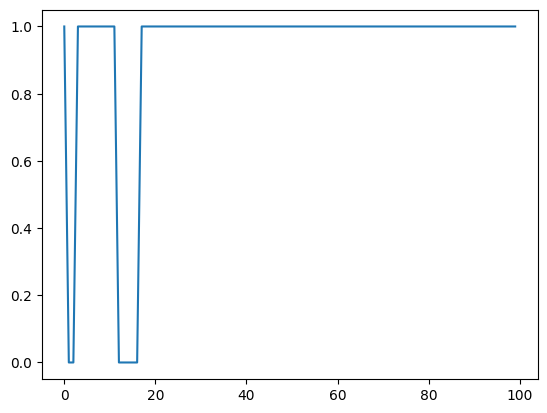

In [10]:
plt.plot(score_log)

## Visualizing the Agent's Path
This cell shows the path taken by the agent from the start state to the terminal state using the learned value function.

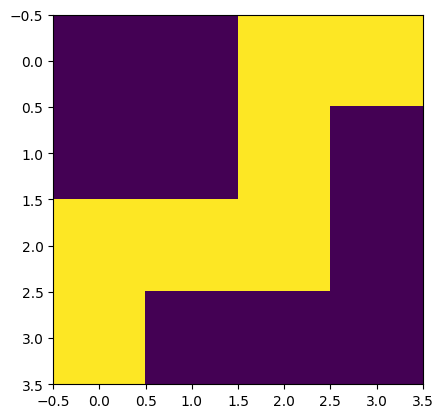

In [11]:
_, state_log = test_agent()
state_view = np.zeros(16)
state_view[state_log] = 1
plt.imshow(state_view.reshape(4,4))